In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib

from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

print(" Bibliotheques importees avec succes !")

 Bibliotheques importees avec succes !


In [2]:
#  Chargement des donnees traitees
with open('../data/donnees_traitees.pkl', 'rb') as f:
    donnees = pickle.load(f)

X_train = donnees['X_train']
X_test = donnees['X_test']
y_train = donnees['y_train']
y_test = donnees['y_test']
noms_colonnes = donnees['noms_colonnes']

print(f" Entrainement : {X_train.shape}")
print(f" Test :         {X_test.shape}")
print(f" Caracteristiques : {noms_colonnes}")

 Entrainement : (1022, 18)
 Test :         (160, 18)
 Caracteristiques : ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'relation']


In [3]:
#  Entrainement de XGBoost avec GridSearchCV
parametres_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'scale_pos_weight': [1, 2, 3]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

recherche_xgb = GridSearchCV(
    xgb, parametres_xgb,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

recherche_xgb.fit(X_train, y_train)

meilleur_xgb = recherche_xgb.best_estimator_

print(f"\n Meilleurs parametres XGBoost : {recherche_xgb.best_params_}")
print(f" Meilleur Recall (CV) : {recherche_xgb.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits

 Meilleurs parametres XGBoost : {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 3}
 Meilleur Recall (CV) : 0.9824


In [4]:
#  Evaluation de XGBoost
y_pred_xgb = meilleur_xgb.predict(X_test)
y_proba_xgb = meilleur_xgb.predict_proba(X_test)[:, 1]

print("=" * 50)
print(" RESULTATS - XGBoost")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb, target_names=['Non TSA', 'TSA']))

resultats_xgb = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'AUC-ROC': roc_auc_score(y_test, y_proba_xgb)
}

for metrique, valeur in resultats_xgb.items():
    print(f"  {metrique} : {valeur:.4f}")

 RESULTATS - XGBoost
              precision    recall  f1-score   support

     Non TSA       0.99      0.72      0.83       128
         TSA       0.46      0.97      0.63        32

    accuracy                           0.77       160
   macro avg       0.73      0.84      0.73       160
weighted avg       0.88      0.77      0.79       160

  Accuracy : 0.7688
  Precision : 0.4627
  Recall : 0.9688
  F1-Score : 0.6263
  AUC-ROC : 0.8983


In [5]:
#  Entrainement du MLP avec GridSearchCV
parametres_mlp = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500]
}

mlp = MLPClassifier(random_state=42, early_stopping=True, validation_fraction=0.15)

recherche_mlp = GridSearchCV(
    mlp, parametres_mlp,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

recherche_mlp.fit(X_train, y_train)

meilleur_mlp = recherche_mlp.best_estimator_

print(f"\n Meilleurs paramètres MLP : {recherche_mlp.best_params_}")
print(f" Meilleur Recall (CV) : {recherche_mlp.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Meilleurs paramètres MLP : {'activation': 'relu', 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01, 'max_iter': 500}
 Meilleur Recall (CV) : 0.9628


In [6]:
#  Evaluation du MLP
y_pred_mlp = meilleur_mlp.predict(X_test)
y_proba_mlp = meilleur_mlp.predict_proba(X_test)[:, 1]

print("=" * 50)
print(" RESULTATS - MLP")
print("=" * 50)
print(classification_report(y_test, y_pred_mlp, target_names=['Non TSA', 'TSA']))

resultats_mlp = {
    'Accuracy': accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall': recall_score(y_test, y_pred_mlp),
    'F1-Score': f1_score(y_test, y_pred_mlp),
    'AUC-ROC': roc_auc_score(y_test, y_proba_mlp)
}

for metrique, valeur in resultats_mlp.items():
    print(f"  {metrique} : {valeur:.4f}")

 RESULTATS - MLP
              precision    recall  f1-score   support

     Non TSA       0.88      0.90      0.89       128
         TSA       0.55      0.50      0.52        32

    accuracy                           0.82       160
   macro avg       0.71      0.70      0.71       160
weighted avg       0.81      0.82      0.82       160

  Accuracy : 0.8187
  Precision : 0.5517
  Recall : 0.5000
  F1-Score : 0.5246
  AUC-ROC : 0.8660


 COMPARAISON DES MODELES
           XGBoost     MLP
Accuracy    0.7688  0.8188
Precision   0.4627  0.5517
Recall      0.9688  0.5000
F1-Score    0.6263  0.5246
AUC-ROC     0.8983  0.8660


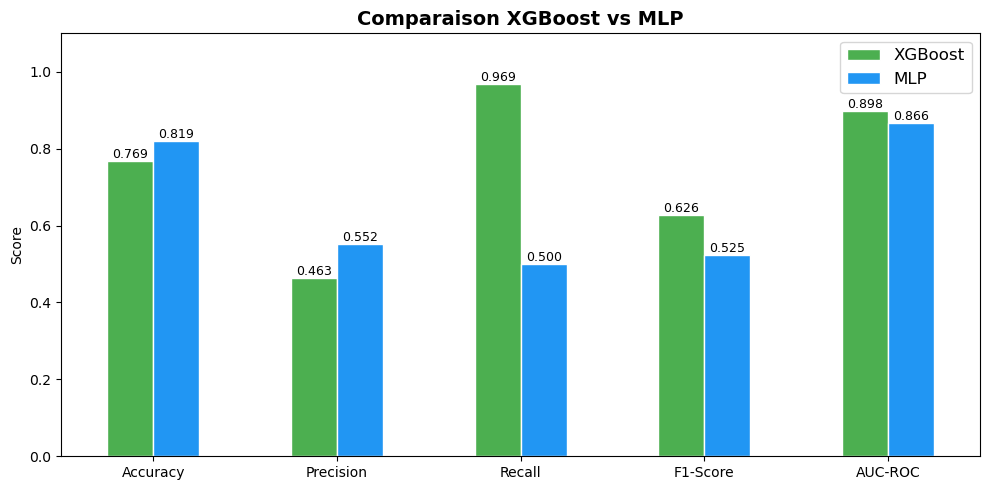


 Meilleur modele : XGBoost (Recall le plus eleve)


In [7]:
# Comparaison des modeles
comparaison = pd.DataFrame({
    'XGBoost': resultats_xgb,
    'MLP': resultats_mlp
})

print("=" * 50)
print(" COMPARAISON DES MODELES")
print("=" * 50)
print(comparaison.round(4))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
comparaison.plot(kind='bar', ax=ax, color=['#4CAF50', '#2196F3'], edgecolor='white')
ax.set_title('Comparaison XGBoost vs MLP', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.1)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.show()

# Identifier le meilleur modele selon le Recall
if resultats_xgb['Recall'] >= resultats_mlp['Recall']:
    print("\n Meilleur modele : XGBoost (Recall le plus eleve)")
else:
    print("\n Meilleur modele : MLP (Recall le plus eleve)")

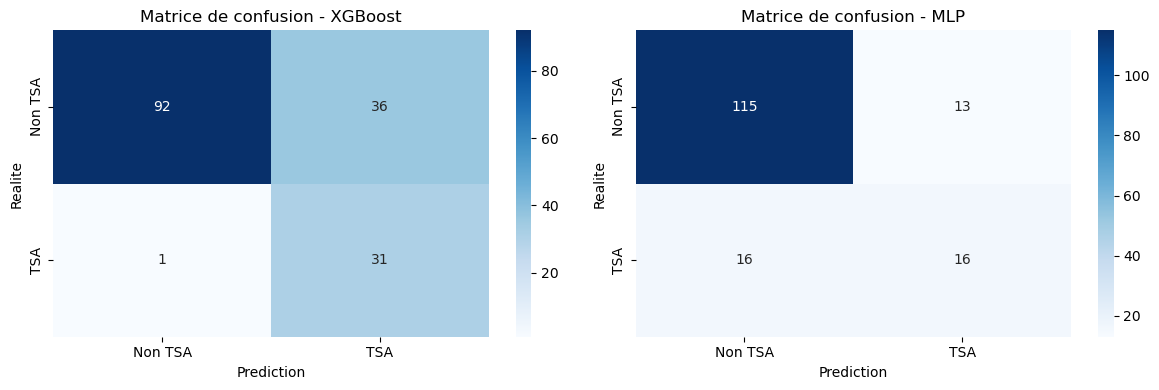

In [8]:
#  Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, titre in zip(axes,
                              [y_pred_xgb, y_pred_mlp],
                              ['XGBoost', 'MLP']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non TSA', 'TSA'],
                yticklabels=['Non TSA', 'TSA'])
    ax.set_title(f'Matrice de confusion - {titre}')
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Realite')

plt.tight_layout()
plt.show()

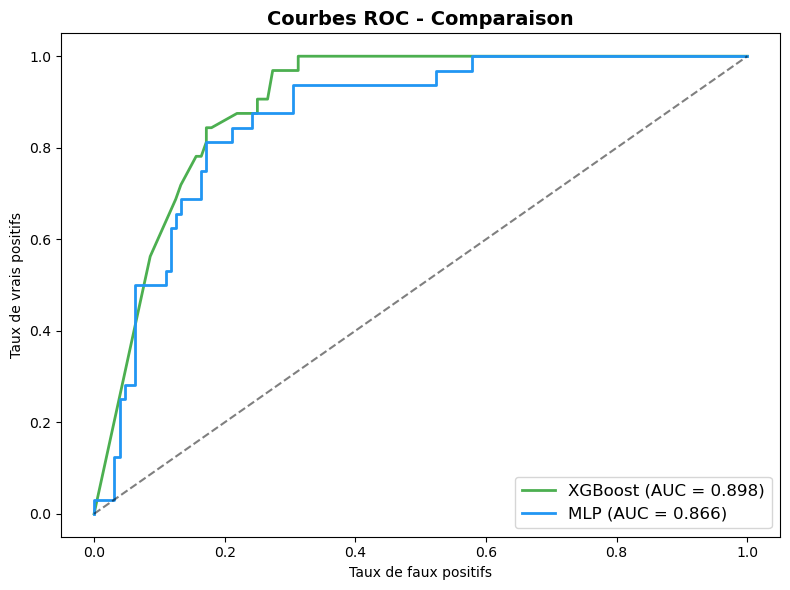

In [9]:
#  Courbes ROC
plt.figure(figsize=(8, 6))

for y_proba, nom, couleur in zip(
    [y_proba_xgb, y_proba_mlp],
    ['XGBoost', 'MLP'],
    ['#4CAF50', '#2196F3']
):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=couleur, linewidth=2, label=f'{nom} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC - Comparaison', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

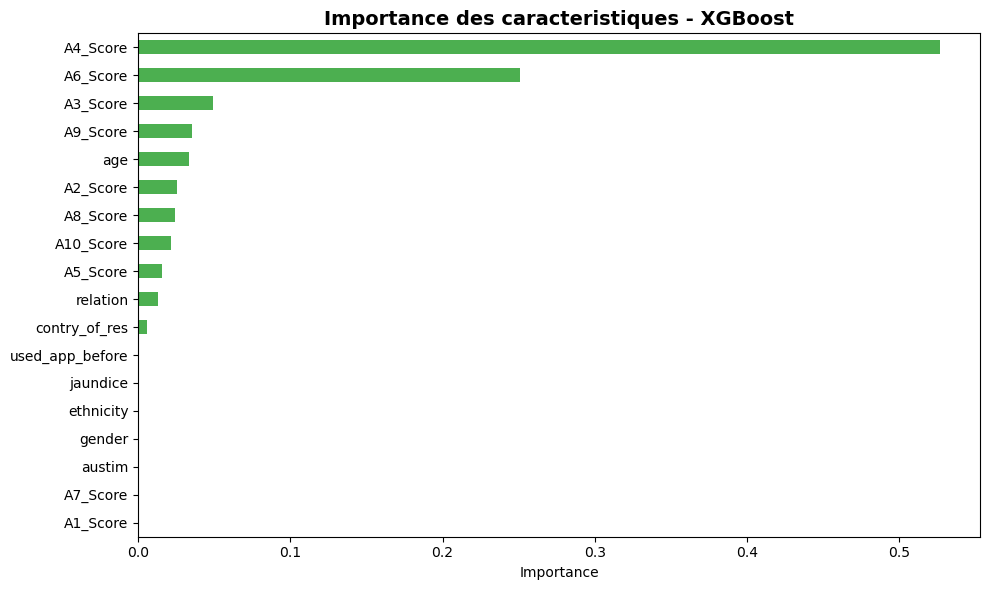

In [10]:
#  Importance des caracteristiques (XGBoost)
importance = pd.Series(
    meilleur_xgb.feature_importances_,
    index=noms_colonnes
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind='barh', color='#4CAF50')
plt.title('Importance des caracteristiques - XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [11]:
#  Sauvegarde du meilleur modele
if resultats_xgb['Recall'] >= resultats_mlp['Recall']:
    meilleur_modele = meilleur_xgb
    nom_modele = 'XGBoost'
else:
    meilleur_modele = meilleur_mlp
    nom_modele = 'MLP'

# Sauvegarder le meilleur modèle
joblib.dump(meilleur_modele, '../saved_models/best_model.pkl')

# Sauvegarder aussi les deux modèles séparément
joblib.dump(meilleur_xgb, '../saved_models/xgboost_model.pkl')
joblib.dump(meilleur_mlp, '../saved_models/mlp_model.pkl')

# Sauvegarder les résultats pour le notebook de comparaison
resultats_finaux = {
    'xgb': resultats_xgb,
    'mlp': resultats_mlp,
    'meilleur': nom_modele,
    'y_test': y_test,
    'y_pred_xgb': y_pred_xgb,
    'y_pred_mlp': y_pred_mlp,
    'y_proba_xgb': y_proba_xgb,
    'y_proba_mlp': y_proba_mlp
}

with open('../data/resultats_modeles.pkl', 'wb') as f:
    pickle.dump(resultats_finaux, f)

print(f"🏆 Meilleur modèle sauvegardé : {nom_modele}")
print(f"   Recall : {max(resultats_xgb['Recall'], resultats_mlp['Recall']):.4f}")
print(f"✅ Fichiers sauvegardés dans '../saved_models/'")

🏆 Meilleur modèle sauvegardé : XGBoost
   Recall : 0.9688
✅ Fichiers sauvegardés dans '../saved_models/'
